First 5 rows
   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Monthly

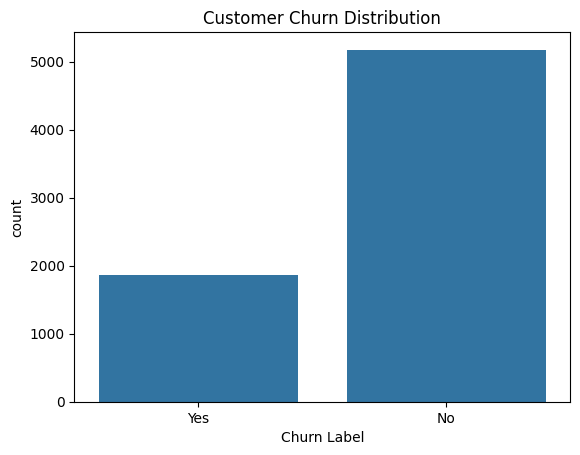

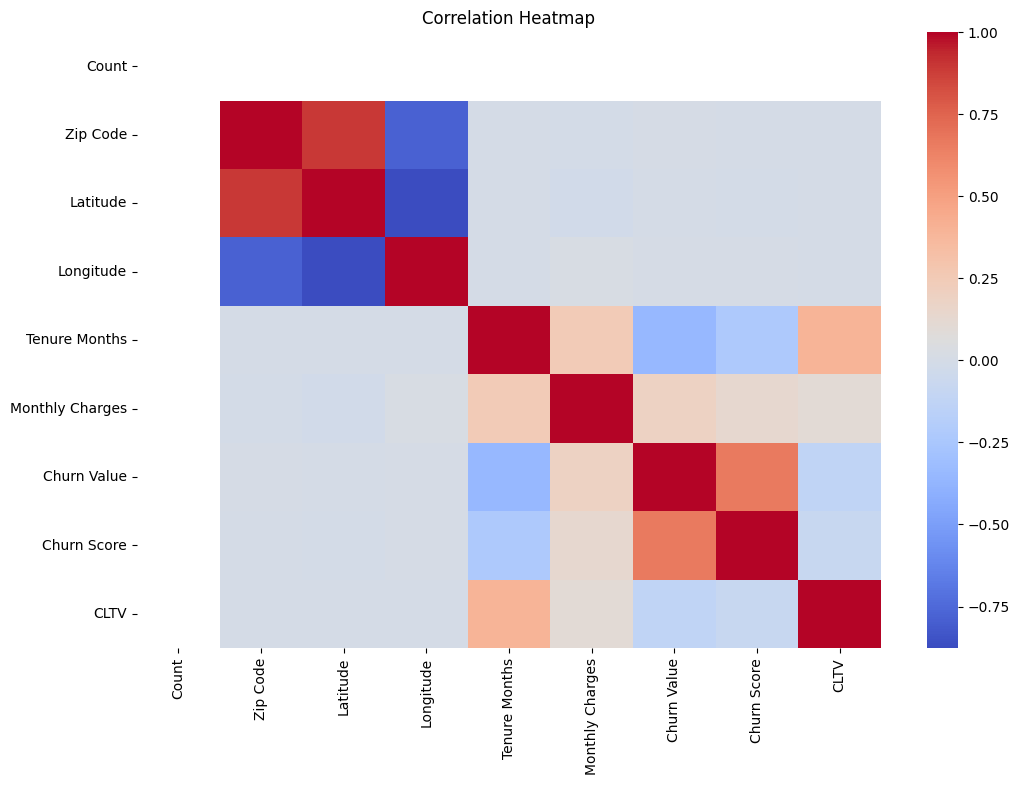


Logistic Regression Results
Accuracy: 0.9138665404637956
Precision: 0.8417508417508418
Recall: 0.8503401360544217
F1 Score: 0.8460236886632826

Decision Tree Results
Accuracy: 0.9200189304306673
Precision: 0.8218125960061444
Recall: 0.9098639455782312
F1 Score: 0.8635996771589992


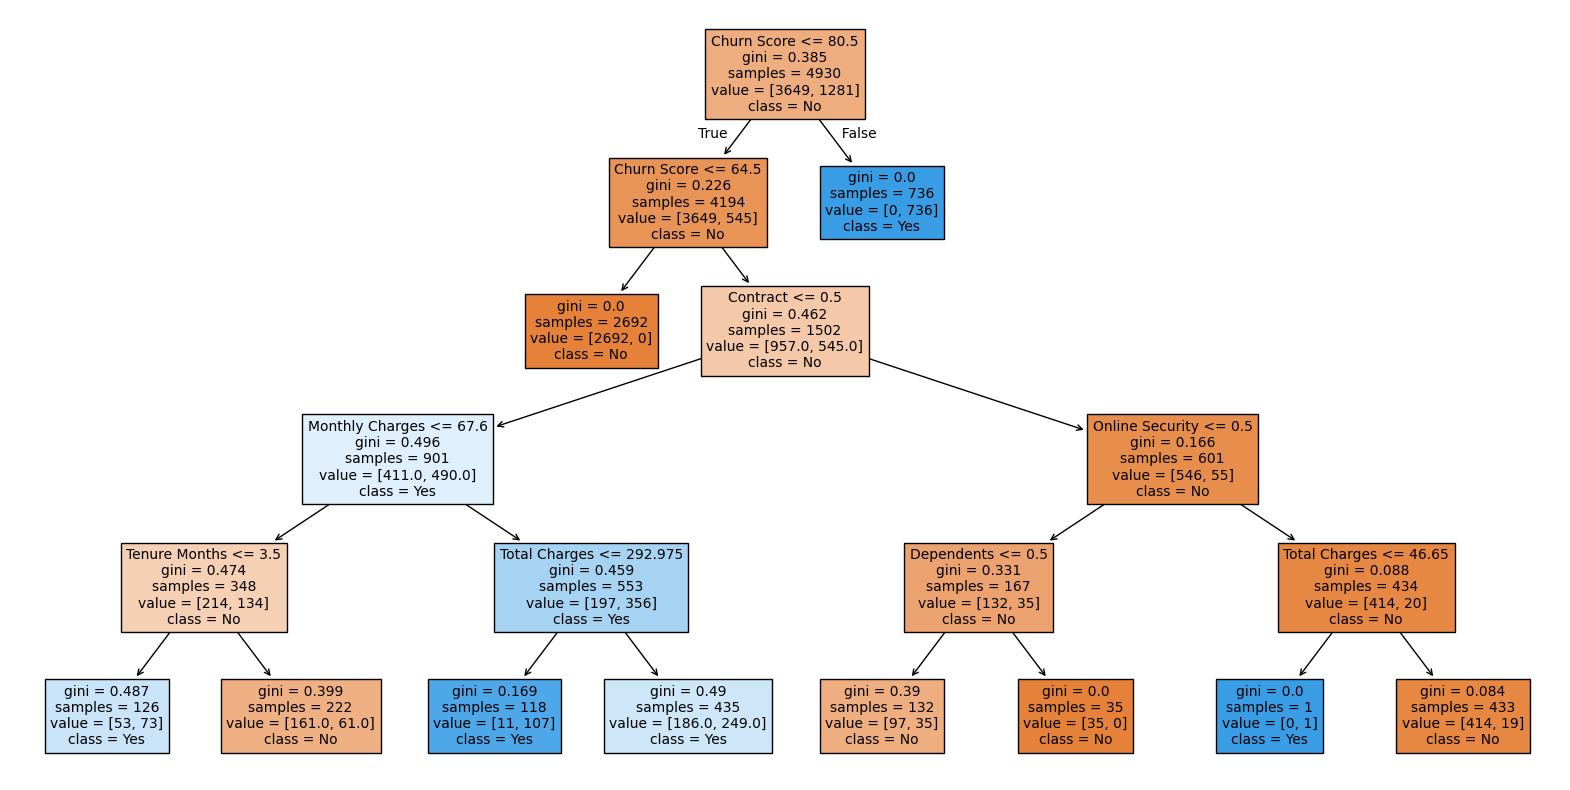

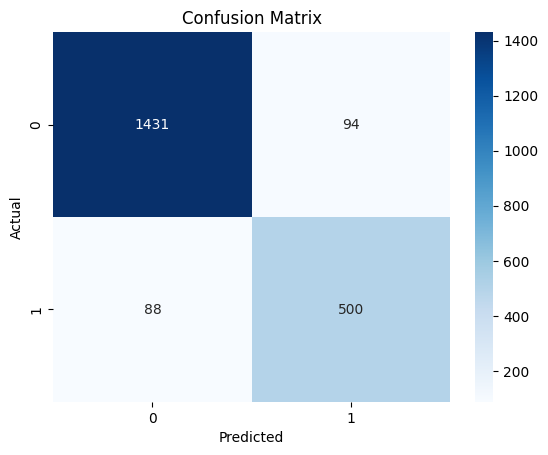


Best Decision Tree Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}
Best Score: 0.91947261663286

Model Comparison
                 Model  Accuracy
0  Logistic Regression  0.913867
1        Decision Tree  0.920019


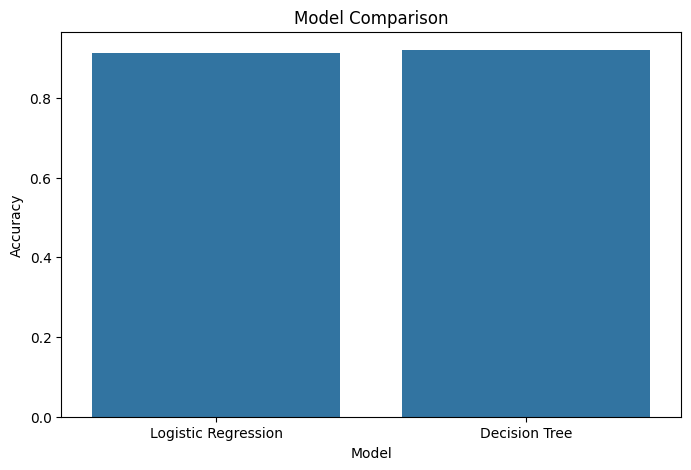

In [6]:
# Customer Churn Prediction using Logistic Regression & Decision Tree
# ============================================================

# 1. Import Libraries
# ---------------------------

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 2. Load Dataset
# ---------------------------

df = pd.read_excel("Telco_customer_churn (1).xlsx")

print("First 5 rows")
print(df.head())

# 3. Exploratory Data Analysis
# ---------------------------

print("\nDataset Shape")
print(df.shape)

print("\nDataset Info")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

# Class distribution
sns.countplot(x="Churn Label", data=df)

plt.title("Customer Churn Distribution")

plt.show()

# Correlation heatmap
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

# 4. Data Preprocessing
# ---------------------------

# Drop columns that will cause leakage or are not useful
df = df.drop([
"CustomerID",
"Country",
"State",
"City",
"Lat Long",
"Churn Reason",
"Churn Label"
], axis=1)

# Convert Total Charges to numeric
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

# Handle missing values
df = df.fillna(df.median(numeric_only=True))

# Encode categorical variables
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

# 5. Feature Selection
# ---------------------------

y = df["Churn Value"]

X = df.drop("Churn Value", axis=1)


# 6. Train Test Split
# ---------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# 7. Feature Scaling
# ---------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# 8. Logistic Regression (L2)
# ---------------------------

lr_l2 = LogisticRegression(max_iter=1000)

lr_l2.fit(X_train_scaled, y_train)

y_pred_lr_l2 = lr_l2.predict(X_test_scaled)

print("\nLogistic Regression Results")

print("Accuracy:", accuracy_score(y_test, y_pred_lr_l2))

print("Precision:", precision_score(y_test, y_pred_lr_l2))

print("Recall:", recall_score(y_test, y_pred_lr_l2))

print("F1 Score:", f1_score(y_test, y_pred_lr_l2))

# 9. Decision Tree (Gini)
# ---------------------------

dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("\nDecision Tree Results")

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("Precision:", precision_score(y_test, y_pred_dt))

print("Recall:", recall_score(y_test, y_pred_dt))

print("F1 Score:", f1_score(y_test, y_pred_dt))

# 10. Decision Tree Visualization
# ---------------------------

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["No","Yes"],
    filled=True
)

plt.show()

# 11. Confusion Matrix
# ---------------------------

cm = confusion_matrix(y_test, y_pred_lr_l2)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# 12. GridSearchCV (Decision Tree)
# ---------------------------

param_grid = {
    "criterion":["gini","entropy"],
    "max_depth":[3,5,10,None],
    "min_samples_split":[2,5,10]
}

grid = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("\nBest Decision Tree Parameters:", grid.best_params_)

print("Best Score:", grid.best_score_)

# 13. Model Comparison
# ---------------------------

results = pd.DataFrame({

"Model":[
"Logistic Regression",
"Decision Tree"
],

"Accuracy":[
accuracy_score(y_test, y_pred_lr_l2),
accuracy_score(y_test, y_pred_dt)
]

})

print("\nModel Comparison")

print(results)

# 14. Visualization
# ---------------------------

plt.figure(figsize=(8,5))

sns.barplot(x="Model", y="Accuracy", data=results)

plt.title("Model Comparison")

plt.show()

# END
